# Model Training 
## Feature Selection

We will be using the cleaned dataset


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [5]:
df = pd.read_csv("Algerian_forest_fires_cleaned_updated_dataset.csv")
df.head()

,Unnamed: 0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [6]:
df.columns

Index(['Unnamed: 0', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC',
       'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

Drop month, day and year column as well as drop unnamed, index, level_0

In [7]:
# df = df.drop(columns= {"day", "month", "year"}, axis = 1)
# df = df.drop(columns  = {'Unnamed: 0', 'level_0', 'index'}, axis= 1)
df.head()

,Unnamed: 0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


Cleaning the Classes column by removing the extra spaces

In [8]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0 ,1 )
df.head()

,Unnamed: 0,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [9]:
df['Classes'].value_counts()

Classes
1    138
0    106
Name: count, dtype: int64

Independent and dependent features

In [10]:
X = df.drop('FWI', axis = 1)  # Dependent Features except FWI
Y = df['FWI']                 # Independent Feature FWI
# X is a DataFrame while Y is Series datatype
print(type(X), type(Y))

<class 'pandas.core.frame.DataFrame'> <class 'pandas.core.series.Series'>


Train test split

In [11]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size= 0.25, random_state= 42)

print(xtrain.shape, xtest.shape)
print(ytrain.shape, ytest.shape)


(183, 12) (61, 12)
(183,) (61,)


Featutre Selection based on correlation


Check for multi-collinearity

<Axes: >

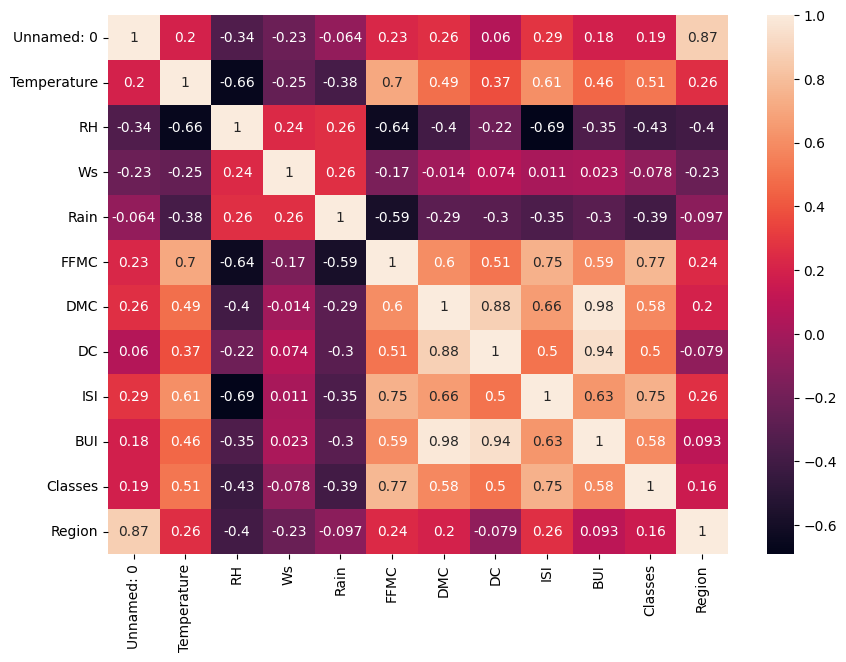

In [12]:
plt.figure(figsize=(10, 7))
corr = xtrain.corr()
sns.heatmap(corr, annot=True)

In [13]:
def correlation(dataset, threshold):
    colCorr = set()
    corrMatrix = dataset.corr()        
    for i in range(len(corrMatrix.columns)):
        for j in range(i):
            if(abs(corrMatrix.iloc[i, j]) > threshold):
                colName = corrMatrix.columns[i]
                colCorr.add(colName)
    
    return colCorr

In [14]:
# c = xtrain.corr()
# unique = set()

# for i in range(len(c.columns)):
#     for j in range(i):
#         if(c.iloc[i, j] > 0.9):
#             unique.add(c.columns[i])

# unique

In [15]:
# threshold = 0.85 is set
highCorr = correlation(xtrain, 0.85)
highCorr

{'BUI', 'DC', 'Region'}

Drop the feautures where correlation in more than 85%

In [16]:
xtrain.drop(columns = highCorr, axis = 1, inplace=True)

In [17]:
xtest.drop(columns = highCorr, axis = 1, inplace= True)

In [18]:
# Checking the shapes
xtrain.shape, xtest.shape

((183, 9), (61, 9))

### Feature Scaling or Standardization



In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
xtrainScaled = scaler.fit_transform(xtrain)
xtestScaled = scaler.transform(xtest)

xtrainScaled

array([[-0.09244309, -0.81085018,  0.16311382, ..., -0.73698402,
        -0.77409606, -1.1098231 ],
       [ 0.84424117,  1.06405791, -0.44884168, ...,  0.7287992 ,
         0.84971776,  0.9010445 ],
       [ 1.46869734, -0.27516216,  0.63907922, ..., -0.51271118,
        -0.21666743,  0.9010445 ],
       ...,
       [-0.41886336, -1.88222624,  0.91105944, ..., -1.07339329,
        -1.08916441, -1.1098231 ],
       [ 0.81585679,  0.26052587, -0.38084663, ...,  0.08000991,
         0.48617735,  0.9010445 ],
       [-0.2769415 , -0.54300617,  0.9790545 , ..., -1.02533482,
        -0.87104017, -1.1098231 ]], shape=(183, 9))

### Box plots to understand the effects of standardization


Text(0.5, 1.0, 'Training data after scaling ')

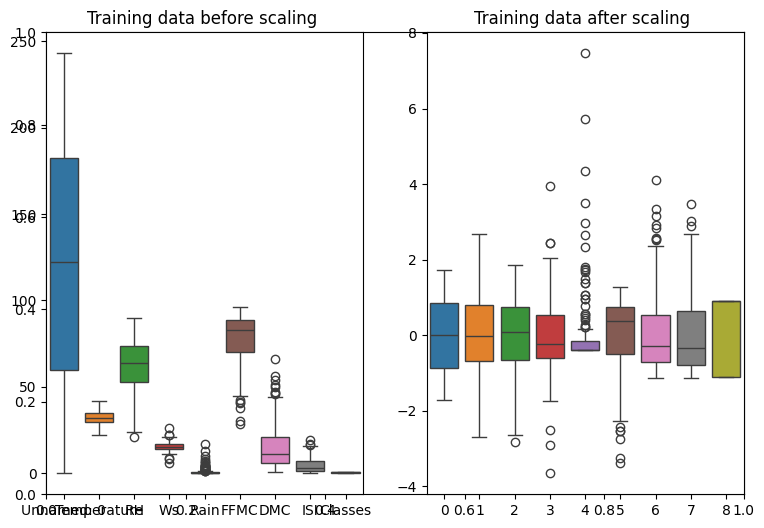

In [20]:
plt.subplots(figsize = (9, 6))
plt.subplot(1, 2, 1)
sns.boxplot(data=xtrain)
plt.title("Training data before scaling ")
plt.subplot(1, 2, 2)
sns.boxplot(data = xtrainScaled)
plt.title("Training data after scaling ")

# Linear Regression Model

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

reg = LinearRegression()
reg.fit(xtrainScaled, ytrain)
ypred = reg.predict(xtestScaled)

mae = mean_absolute_error(ytest, ypred)
rscore = r2_score(ytest, ypred)

print('Coeffient', reg.coef_)
print('Intercept', reg.intercept_)

print("Mean Absoute Error", mae)
print("R2_score", rscore)

Coeffient [-0.27474421 -0.02949399 -0.03559137  0.06684394 -0.04417621 -0.79925763
  3.58511577  4.62702596  0.49591193]
Intercept 6.9568306010928955
Mean Absoute Error 0.5781540068563618
R2_score 0.9895676160417731


Comparison

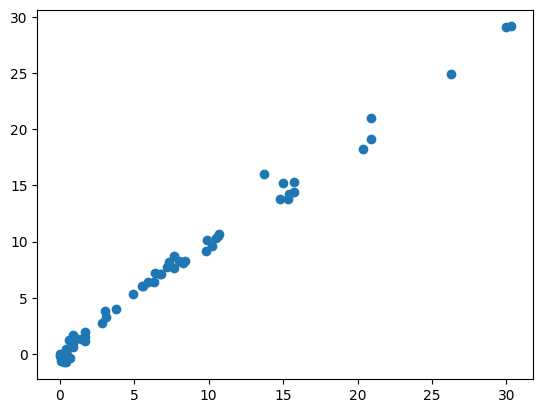

In [22]:
plt.scatter(ytest, ypred)


# Ridge and Lasso Regression Models


## Lasso Regression Model


Coeffient [ 0.          0.         -0.          0.         -0.          0.
  2.86222891  3.82115824  0.        ]
Intercept 6.9568306010928955
Mean Absoute Error 1.186250714786231
R2_score 0.9527187216579601


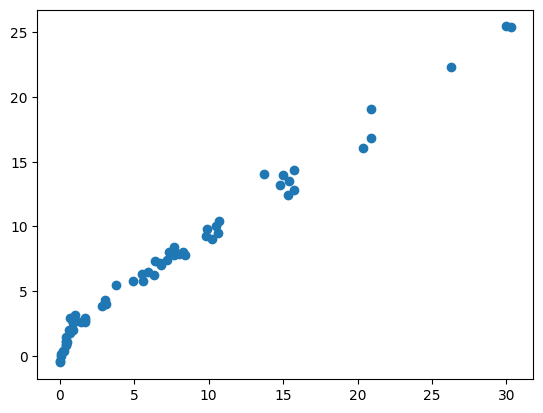

In [23]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

lassoreg = Lasso()
lassoreg.fit(xtrainScaled, ytrain)
ypred = lassoreg.predict(xtestScaled)

mae = mean_absolute_error(ytest, ypred)
rscore = r2_score(ytest, ypred)

print('Coeffient', lassoreg.coef_)
print('Intercept', lassoreg.intercept_)

print("Mean Absoute Error", mae)
print("R2_score", rscore)

plt.scatter(ytest, ypred)        # Comparison

## Cross Validation Lasso Model



In [24]:
from sklearn.linear_model import LassoCV

lassocv = LassoCV(cv= 5)
lassocv.fit(xtrainScaled, ytrain)

,"eps eps: float, default=1e-3Length of the path. ``eps=1e-3`` means that``alpha_min / alpha_max = 1e-3``.",0.001
,"n_alphas n_alphas: int, default=100Number of alphas along the regularization path... deprecated:: 1.7 `n_alphas` was deprecated in 1.7 and will be removed in 1.9. Use `alphas` instead.",'deprecated'
,"alphas alphas: array-like or int, default=NoneValues of alphas to test along the regularization path.If int, `alphas` values are generated automatically.If array-like, list of alpha values to use... versionchanged:: 1.7 `alphas` accepts an integer value which removes the need to pass `n_alphas`... deprecated:: 1.7 `alphas=None` was deprecated in 1.7 and will be removed in 1.9, at which point the default value will be set to 100.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: 'auto', bool or array-like of shape (n_features, n_features), default='auto'Whether to use a precomputed Gram matrix to speed upcalculations. If set to ``'auto'`` let us decide. The Grammatrix can also be passed as argument.",'auto'
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``.",0.0001
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"cv cv: int, cross-validation generator or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- int, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For int/None inputs, :class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: bool or int, default=FalseAmount of verbosity.",False
,"n_jobs n_jobs: int, default=NoneNumber of CPUs to use during the cross validation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [25]:
lassocv.alpha_

np.float64(0.021954072695626763)

In [26]:
lassocv.mse_path_

array([[58.91577975, 44.30507327, 54.66745457, 72.80979441, 36.97248445],
       [54.08220408, 39.12388795, 49.94600549, 69.53150545, 32.4786371 ],
       [48.6362257 , 34.5159559 , 43.94622556, 63.41332128, 28.69216696],
       [43.00655732, 30.48823376, 38.28047424, 58.00762221, 24.90656785],
       [38.00403596, 26.96649955, 33.35790218, 53.22729559, 21.43636669],
       [33.62422836, 23.88611375, 29.08128393, 48.99619187, 18.4914339 ],
       [29.78781779, 21.19074095, 25.36616095, 45.24772242, 15.99826876],
       [26.42585112, 18.83133423, 22.13893688, 40.44635228, 13.89316887],
       [23.47823349, 16.76515197, 19.33610022, 35.76154005, 12.12183164],
       [20.89258276, 14.9549708 , 16.90195488, 31.66385988, 10.63652162],
       [18.62303629, 13.36829407, 14.78823449, 28.07862112,  9.39625565],
       [16.63019294, 11.97685411, 12.9529759 , 24.94051245,  8.36564012],
       [14.87910455, 10.75599145, 11.35969704, 22.19192458,  7.51412578],
       [13.33948285,  9.68420663,  9.9

Mean Squared Error  0.6355659746074688
R2 score  <function r2_score at 0x0000019A97689850>


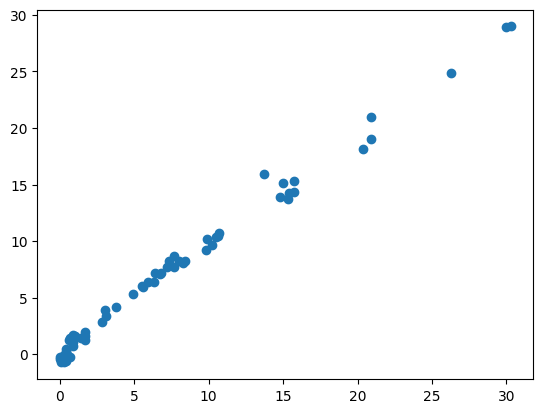

In [27]:
ypredLassoCV = lassocv.predict(xtestScaled)
plt.scatter(ytest, ypredLassoCV)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(ypredLassoCV, ytest)
r2score = r2_score(ypredLassoCV, ytest)

print("Mean Squared Error ", mse)
print("R2 score ", r2_score)

## Ridge Regression Model

Coeffient [-0.26399033 -0.0252782  -0.06596419  0.08601814 -0.04112887 -0.75997347
  3.56908964  4.53564677  0.52552963]
Intercept 6.9568306010928955
Mean Absoute Error 0.6012558574010286
R2_score 0.9889226386288306


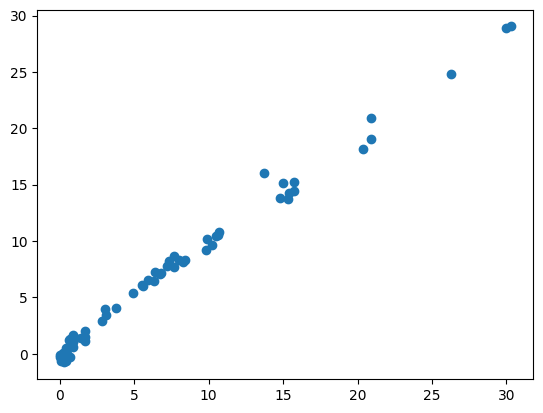

In [28]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

ridgereg = Ridge()
ridgereg.fit(xtrainScaled, ytrain)
ypred = ridgereg.predict(xtestScaled)

mae = mean_absolute_error(ytest, ypred)
rscore = r2_score(ytest, ypred)

print('Coeffient', ridgereg.coef_)
print('Intercept', ridgereg.intercept_)

print("Mean Absoute Error", mae)
print("R2_score", rscore)

plt.scatter(ytest, ypred)              # Comparison

## Cross Validation Ridge

In [29]:
from sklearn.linear_model import RidgeCV

rcv = RidgeCV()
rcv.fit(xtrainScaled, ytrain)



,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-One-Out cross-validation- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used, else,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.",None
,"gcv_mode gcv_mode: {'auto', 'svd', 'eigen'}, default='auto'Flag indicating which strategy to use when performingLeave-One-Out Cross-Validation. Options are:: 'auto' : use 'svd' if n_samples > n_features, otherwise use 'eigen' 'svd' : force use of singular value decomposition of X when X is dense, eigenvalue decomposition of X^T.X when X is sparse. 'eigen' : force computation via eigendecomposition of X.X^TThe 'auto' mode is the default and is intended to pick the cheaperoption of the two depending on the shape of the training data.",None
,"store_cv_results store_cv_results: bool, default=FalseFlag indicating if the cross-validation values corresponding toeach alpha should be stored in the ``cv_results_`` attribute (seebelow). This flag is only compatible with ``cv=None`` (i.e. usingLeave-One-Out Cross-Validation)... versionchanged:: 1.5 Parameter name changed from `store_cv_values` to `store_cv_results`.",False
,"alpha_per_target alpha_per_target: bool, default=FalseFlag indicating whether to optimize the alpha value (picked from the`alphas` parameter list) for each target separately (for multi-outputsettings: multiple prediction targets). When set to `True`, afterfitting, the `alpha_` attribute will contain a value for each target.When set to `False`, a single alpha is used for all targets... versionadded:: 0.24",False


# Elastic Net Regression Model

Coeffient [ 0.          0.15857099 -0.3646238   0.         -0.          0.36305602
  2.28012365  2.28528469  0.8814855 ]
Intercept 6.9568306010928955
Mean Absoute Error 1.9100566301813486
R2_score 0.877659100318675


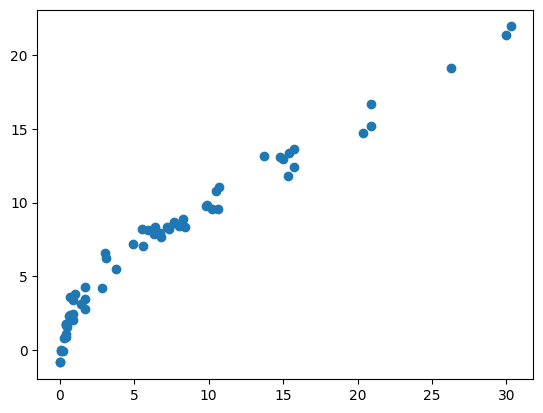

In [30]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

enetreg = ElasticNet()
enetreg.fit(xtrainScaled, ytrain)
ypred = enetreg.predict(xtestScaled)

mae = mean_absolute_error(ytest, ypred)
rscore = r2_score(ytest, ypred)

print('Coeffient', enetreg.coef_)
print('Intercept', enetreg.intercept_)

print("Mean Absoute Error", mae)
print("R2_score", rscore)

plt.scatter(ytest, ypred)              # Comparison

# Pickling

In [31]:
import pickle

pickle.dump(ridgereg, open('ridgereg.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

Changing the classes column elements to 0 for not fire and 1 for fire


In [3]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

NameError: name 'df' is not defined